In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

fin_df = pd.read_csv("../data/financials.csv")
sap_revenue = pd.read_csv("../data/sap_revenue.csv")

print("Datos cargados OK")
print(fin_df[["company", "ev_revenue", "ev_ebitda", "pe_ratio", "gross_margins", "revenue_growth"]])

Datos cargados OK
      company  ev_revenue  ev_ebitda   pe_ratio  gross_margins  revenue_growth
0         SAP       5.019     16.151  22.867790        0.73719           0.060
1      Oracle       8.092     17.875  24.018835        0.65822           0.206
2  Salesforce       3.894     12.932  19.225695        0.77644           0.133
3   Microsoft       9.262     15.982  23.257294        0.68309           0.183


In [2]:
# Formatear métricas para la tabla
comp_table = fin_df[["company", "ev_revenue", "ev_ebitda", "pe_ratio", "gross_margins", "revenue_growth"]].copy()

comp_table["gross_margins"]   = (comp_table["gross_margins"] * 100).round(1)
comp_table["revenue_growth"]  = (comp_table["revenue_growth"] * 100).round(1)
comp_table["ev_revenue"]      = comp_table["ev_revenue"].round(2)
comp_table["ev_ebitda"]       = comp_table["ev_ebitda"].round(2)
comp_table["pe_ratio"]        = comp_table["pe_ratio"].round(1)

# Calcular mediana del grupo (peer median)
medians = comp_table[["ev_revenue", "ev_ebitda", "pe_ratio", "gross_margins", "revenue_growth"]].median()
median_row = pd.DataFrame([{
    "company":        "Peer Median",
    "ev_revenue":     round(medians["ev_revenue"], 2),
    "ev_ebitda":      round(medians["ev_ebitda"], 2),
    "pe_ratio":       round(medians["pe_ratio"], 1),
    "gross_margins":  round(medians["gross_margins"], 1),
    "revenue_growth": round(medians["revenue_growth"], 1),
}])

comp_table = pd.concat([comp_table, median_row], ignore_index=True)

print("Comparable Company Analysis:")
print(comp_table.to_string(index=False))

Comparable Company Analysis:
    company  ev_revenue  ev_ebitda  pe_ratio  gross_margins  revenue_growth
        SAP        5.02      16.15      22.9           73.7             6.0
     Oracle        8.09      17.88      24.0           65.8            20.6
 Salesforce        3.89      12.93      19.2           77.6            13.3
  Microsoft        9.26      15.98      23.3           68.3            18.3
Peer Median        6.56      16.06      23.1           71.0            15.8


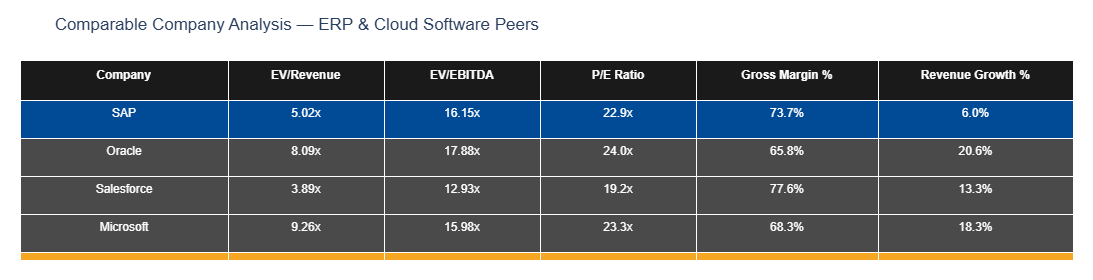

In [3]:
# Colores: SAP en azul, peers en gris, mediana en naranja
row_colors = []
for company in comp_table["company"]:
    if company == "SAP":
        row_colors.append("#004A96")
    elif company == "Peer Median":
        row_colors.append("#F5A623")
    else:
        row_colors.append("#4A4A4A")

fig = go.Figure(data=[go.Table(
    columnwidth=[160, 120, 120, 120, 140, 150],
    header=dict(
        values=[
            "<b>Company</b>",
            "<b>EV/Revenue</b>",
            "<b>EV/EBITDA</b>",
            "<b>P/E Ratio</b>",
            "<b>Gross Margin %</b>",
            "<b>Revenue Growth %</b>"
        ],
        fill_color="#1a1a1a",
        font=dict(color="white", size=12, family="Arial"),
        align="center",
        height=40
    ),
    cells=dict(
        values=[
            comp_table["company"],
            comp_table["ev_revenue"].astype(str) + "x",
            comp_table["ev_ebitda"].astype(str) + "x",
            comp_table["pe_ratio"].astype(str) + "x",
            comp_table["gross_margins"].astype(str) + "%",
            comp_table["revenue_growth"].astype(str) + "%",
        ],
        fill_color=[row_colors],
        font=dict(color="white", size=12, family="Arial"),
        align="center",
        height=38
    )
)])

fig.update_layout(
    title="Comparable Company Analysis — ERP & Cloud Software Peers",
    font=dict(family="Arial", size=12),
    margin=dict(l=20, r=20, t=60, b=20),
    height=280
)

fig.show()

In [4]:
sap = fin_df[fin_df["company"] == "SAP"].iloc[0]
peers = fin_df[fin_df["company"] != "SAP"]

peer_median_ev_rev  = peers["ev_revenue"].median()
peer_median_ev_ebit = peers["ev_ebitda"].median()

sap_revenue_ttm = sap["revenue_ttm"]
sap_ebitda      = sap["ebitda"]
sap_ev_actual   = sap["enterprise_value"]

implied_ev_by_revenue = peer_median_ev_rev  * sap_revenue_ttm
implied_ev_by_ebitda  = peer_median_ev_ebit * sap_ebitda

upside_revenue = ((implied_ev_by_revenue - sap_ev_actual) / sap_ev_actual * 100).round(1)
upside_ebitda  = ((implied_ev_by_ebitda  - sap_ev_actual) / sap_ev_actual * 100).round(1)

print("SAP Implied Valuation vs Current:")
print(f"  Current EV:                  ${sap_ev_actual/1e9:.1f}bn")
print(f"  Implied EV (EV/Revenue):     ${implied_ev_by_revenue/1e9:.1f}bn  →  {upside_revenue:+.1f}% vs current")
print(f"  Implied EV (EV/EBITDA):      ${implied_ev_by_ebitda/1e9:.1f}bn  →  {upside_ebitda:+.1f}% vs current")
print(f"\n  Peer Median EV/Revenue: {peer_median_ev_rev:.2f}x  vs SAP: {sap['ev_revenue']:.2f}x")
print(f"  Peer Median EV/EBITDA:  {peer_median_ev_ebit:.2f}x  vs SAP: {sap['ev_ebitda']:.2f}x")

SAP Implied Valuation vs Current:
  Current EV:                  $187.4bn
  Implied EV (EV/Revenue):     $302.2bn  →  +61.2% vs current
  Implied EV (EV/EBITDA):      $185.5bn  →  -1.0% vs current

  Peer Median EV/Revenue: 8.09x  vs SAP: 5.02x
  Peer Median EV/EBITDA:  15.98x  vs SAP: 16.15x


In [5]:
comp_table.to_csv("../data/comparable_analysis.csv", index=False)
print("Guardado OK")

Guardado OK
